# Results analysis

Reads the generated files in `results/`. Nothing is recomputed here, so this
notebook cannot disagree with the README.

Run the pipeline first (see README "Reproducing").


In [1]:
import json
from pathlib import Path
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
R = ROOT / "results"
pd.set_option("display.width", 200)

## 1. Corpus and panel

In [2]:
corpus = json.loads((R / "sentiment/corpus_stats.json").read_text())
panel_stats = json.loads((R / "forecasting/panel_stats.json").read_text())
pd.Series({**corpus, **panel_stats}).to_frame("value")

,value
raw_lines_parsed,119844
distinct_tweets,95924
tweets_assigned,118600
pct_rolled_to_later_session,0.42798
ticker_sessions,23509
n_tickers,87
session_min,2014-01-02
session_max,2016-04-01
panel_rows,48838
rows_with_target,48838


`pct_rolled_to_later_session` is the headline alignment number: the share of
tweets that a naive calendar-date grouping would have placed in the wrong
session.

## 2. Sentiment classifier selection

In [3]:
sent = pd.read_csv(R / "sentiment/model_comparison.csv")
sel = json.loads((R / "sentiment/selected_model.json").read_text())
print(sel["selection_criterion"])
print("top CV:", sel["top_cv_model"], "| within 1 SE:", sel["models_within_1se"])
print("selected:", sel["selected_model"])
sent

one-standard-error rule on 5-fold CV ROC-AUC (train split only); among models within 1 SE of the best, the least complex is chosen
top CV: TF-IDF + LinearSVC (calibrated) | within 1 SE: ['TF-IDF + LogisticRegression', 'TF-IDF + LinearSVC (calibrated)']
selected: TF-IDF + LogisticRegression


,model,cv_roc_auc,test_accuracy,test_f1,test_roc_auc,cv_roc_auc_se,complexity_rank
0,VADER (unsupervised baseline),NaN,0.672994,0.765905,0.650054,NaN,NaN
1,TF-IDF + MultinomialNB,0.831996,0.737705,0.824683,0.865677,0.006542,0.0
2,TF-IDF + LogisticRegression,0.850351,0.778257,0.844148,0.871258,0.002884,1.0
3,TF-IDF + LinearSVC (calibrated),0.853689,0.802416,0.850033,0.872268,0.003864,2.0


## 3. Main model comparison

The zero baseline is the reference, not naive persistence.

In [4]:
mc = pd.read_csv(R / "forecasting/model_comparison.csv")
mc[mc.target == "ret_fwd_1"]

,universe,target,model,n,rmse,mae,dir_acc
0,all tickers (n=87),ret_fwd_1,Zero baseline,24621,0.016240,0.011370,0.000000
1,all tickers (n=87),ret_fwd_1,Naive persistence,24621,0.022862,0.016374,0.484656
2,all tickers (n=87),ret_fwd_1,XGBoost (market-only),24621,0.016328,0.011456,0.492727
3,all tickers (n=87),ret_fwd_1,XGBoost (market + sentiment),24621,0.016307,0.011447,0.491949
8,high-coverage (n=11),ret_fwd_1,Zero baseline,3113,0.017782,0.012246,0.000000
9,high-coverage (n=11),ret_fwd_1,Naive persistence,3113,0.024626,0.017699,0.485299
10,high-coverage (n=11),ret_fwd_1,XGBoost (market-only),3113,0.018162,0.012541,0.515347
11,high-coverage (n=11),ret_fwd_1,XGBoost (market + sentiment),3113,0.018095,0.012517,0.498869


In [5]:
# How does each model compare to predicting zero?
for (u, t), g in mc.groupby(["universe", "target"]):
    z = g[g.model == "Zero baseline"]["rmse"].iloc[0]
    g = g.assign(rmse_vs_zero_pct=100 * (g["rmse"] / z - 1))
    print(f"\n{u} | {t}")
    print(g[["model", "rmse", "rmse_vs_zero_pct", "dir_acc"]].to_string(index=False))


all tickers (n=87) | ret_fwd_1
                       model     rmse  rmse_vs_zero_pct  dir_acc
               Zero baseline 0.016240          0.000000 0.000000
           Naive persistence 0.022862         40.772348 0.484656
       XGBoost (market-only) 0.016328          0.543268 0.492727
XGBoost (market + sentiment) 0.016307          0.409911 0.491949

all tickers (n=87) | ret_fwd_3
                       model     rmse  rmse_vs_zero_pct  dir_acc
               Zero baseline 0.028205          0.000000 0.000000
           Naive persistence 0.032758         16.141817 0.485014
       XGBoost (market-only) 0.028325          0.425922 0.501081
XGBoost (market + sentiment) 0.028332          0.451940 0.502426

high-coverage (n=11) | ret_fwd_1
                       model     rmse  rmse_vs_zero_pct  dir_acc
               Zero baseline 0.017782          0.000000 0.000000
           Naive persistence 0.024626         38.491699 0.485299
       XGBoost (market-only) 0.018162          2.140148 0

Every learned model is *worse* than predicting zero on RMSE. That is the
expected result: daily returns are close to unpredictable, so the
unconditional mean minimises squared error.

## 4. Sentiment ablation

In [6]:
abl = pd.read_csv(R / "forecasting/ablation.csv")
abl

,universe,horizon,metric,delta,ci_low,ci_high,p_value,significant_at_5pct
0,all tickers (n=87),h1,rmse,-0.000022,-0.000037,-7.228525e-06,0.004,True
1,all tickers (n=87),h1,mae,-0.000009,-0.000018,-7.300433e-07,0.031,True
2,all tickers (n=87),h1,dir_acc,-0.000778,-0.004752,2.908894e-03,0.676,False
3,all tickers (n=87),h3,rmse,0.000007,-0.000023,3.898650e-05,0.623,False
4,all tickers (n=87),h3,mae,-0.000008,-0.000026,9.257961e-06,0.366,False
5,all tickers (n=87),h3,dir_acc,0.001346,-0.002324,5.015720e-03,0.468,False
6,high-coverage (n=11),h1,rmse,-0.000067,-0.000161,2.721347e-05,0.151,False
7,high-coverage (n=11),h1,mae,-0.000024,-0.000087,3.886318e-05,0.445,False
8,high-coverage (n=11),h1,dir_acc,-0.016478,-0.031685,-1.621192e-03,0.027,True
9,high-coverage (n=11),h3,rmse,-0.000159,-0.000291,-3.187207e-05,0.010,True


In [7]:
# Effect sizes relative to the market-only baseline they are measured against.
base = mc[mc.model == "XGBoost (market-only)"]
rows = []
for _, r in abl[abl.metric == "rmse"].iterrows():
    h = int(r["horizon"].lstrip("h"))
    b = base[(base.universe == r["universe"]) & (base.target == f"ret_fwd_{h}")]["rmse"].iloc[0]
    rows.append({"universe": r["universe"], "horizon": r["horizon"],
                 "abs_delta": r["delta"], "rel_pct": 100 * r["delta"] / b,
                 "p": r["p_value"], "sig": r["significant_at_5pct"]})
pd.DataFrame(rows)

,universe,horizon,abs_delta,rel_pct,p,sig
0,all tickers (n=87),h1,-0.000022,-0.132637,0.004,True
1,all tickers (n=87),h3,0.000007,0.025908,0.623,False
2,high-coverage (n=11),h1,-0.000067,-0.371365,0.151,False
3,high-coverage (n=11),h3,-0.000159,-0.497083,0.010,True


Statistically significant at n=24,621, but the relative effect is around
0.13%. Statistical significance and economic significance are different
questions, and only the second one matters here.

## 5. Robustness

In [8]:
rob = pd.read_csv(R / "forecasting/robustness.csv")
cols = ["universe", "horizon", "dimension", "subgroup", "n",
        "rmse_rel_pct", "rmse_p", "rmse_sig"]
rob[rob.dimension == "trailing volatility"][cols]

,universe,horizon,dimension,subgroup,n,rmse_rel_pct,rmse_p,rmse_sig
0,all tickers (n=87),1d,trailing volatility,low,8207,-0.014549,0.652,False
1,all tickers (n=87),1d,trailing volatility,mid,8207,-0.063576,0.196,False
2,all tickers (n=87),1d,trailing volatility,high,8207,-0.198253,0.009,True
6,all tickers (n=87),3d,trailing volatility,low,8207,-0.087345,0.011,True
7,all tickers (n=87),3d,trailing volatility,mid,8207,-0.011710,0.785,False
8,all tickers (n=87),3d,trailing volatility,high,8207,0.076590,0.419,False
12,high-coverage (n=11),1d,trailing volatility,low,1038,0.323970,0.408,False
13,high-coverage (n=11),1d,trailing volatility,mid,1037,0.415888,0.375,False
14,high-coverage (n=11),1d,trailing volatility,high,1038,-1.110657,0.003,True
16,high-coverage (n=11),3d,trailing volatility,low,1038,0.189928,0.592,False


In [9]:
n_sig = int(rob.rmse_sig.sum())
n_help = int(((rob.rmse_delta < 0) & rob.rmse_sig).sum())
print(f"subgroups tested : {len(rob)}")
print(f"significant      : {n_sig}  (helps {n_help}, hurts {n_sig - n_help})")
print(f"expected by chance at alpha=0.05: {0.05 * len(rob):.1f}")
print("\nNote: subgroups overlap and are not independent tests.")

subgroups tested : 20
significant      : 6  (helps 6, hurts 0)
expected by chance at alpha=0.05: 1.0

Note: subgroups overlap and are not independent tests.


## 6. Per-ticker models

In [10]:
pt = pd.read_csv(R / "forecasting/per_ticker_results.csv")
pt[pt.space == "return"].groupby("model")[["rmse", "mae", "dir_acc"]].mean().sort_values("rmse")

,rmse,mae,dir_acc
model,,,
Zero baseline,0.016946,0.011885,0.000000
ARIMA (per-ticker),0.016961,0.011896,0.506003
Naive persistence,0.023531,0.017107,0.477019
Prophet (per-ticker),0.093389,0.070786,0.501365


In [11]:
# ARIMA vs zero baseline, ticker by ticker
piv = pt[pt.space == "return"].pivot(index="ticker", columns="model", values="rmse")
piv["arima_beats_zero"] = piv["ARIMA (per-ticker)"] < piv["Zero baseline"]
print(f"ARIMA wins on {int(piv.arima_beats_zero.sum())}/{len(piv)} tickers")
piv

ARIMA wins on 4/10 tickers


model,ARIMA (per-ticker),Naive persistence,Prophet (per-ticker),Zero baseline,arima_beats_zero
ticker,,,,,
AAPL,0.016968,0.024608,0.058791,0.016886,False
AMZN,0.021816,0.030740,0.190587,0.021840,True
BAC,0.018293,0.025610,0.108657,0.018269,False
D,0.010317,0.014923,0.069978,0.010304,False
FB,0.019495,0.026577,0.096469,0.019582,True
GE,0.014532,0.020655,0.057339,0.014534,True
GOOG,0.018515,0.025000,0.083061,0.018519,True
IEP,0.022257,0.028751,0.131245,0.022248,False
PFE,0.012483,0.017567,0.071125,0.012466,False


In [12]:
# MAPE is reported only here, where the denominator is a positive price.
pt[pt.space == "price"].groupby("model")[["rmse", "mae", "mape"]].mean()

,rmse,mae,mape
model,,,
Prophet (price),18.553959,14.609718,0.070707
Random walk (price),3.075389,2.071590,0.011858


In [13]:
adf = pd.read_csv(R / "forecasting/stationarity_tests.csv")
print(f"returns   stationary at 5%: {(adf.adf_p_returns < 0.05).sum()}/{len(adf)}")
print(f"log price stationary at 5%: {(adf.adf_p_log_price < 0.05).sum()}/{len(adf)}")
adf

returns   stationary at 5%: 10/10
log price stationary at 5%: 1/10


,ticker,adf_p_returns,adf_p_log_price
0,AAPL,5.416864e-29,0.970558
1,FB,8.824810e-19,0.437196
2,AMZN,5.658851e-29,0.118879
3,D,5.693758e-30,0.139874
4,BAC,1.751454e-29,0.171562
5,PFE,6.132558e-29,0.871695
6,GE,2.169650e-14,0.028314
7,XOM,1.799585e-08,0.396589
8,IEP,4.216775e-10,0.055342
9,GOOG,2.370448e-29,0.191259


This is what justifies `d=0` on returns rather than an arbitrary choice.

## 7. Figures

01_coverage.png


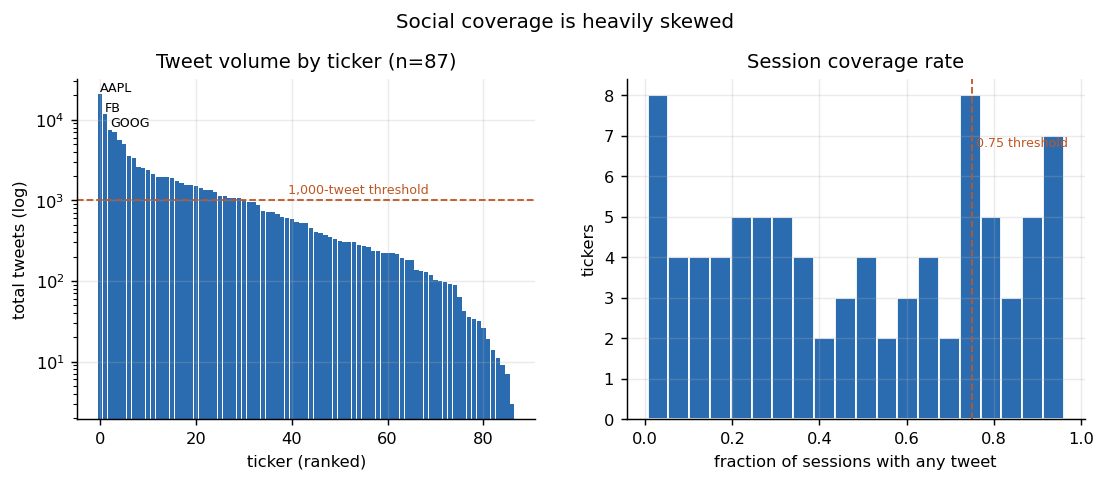

02_sentiment_models.png


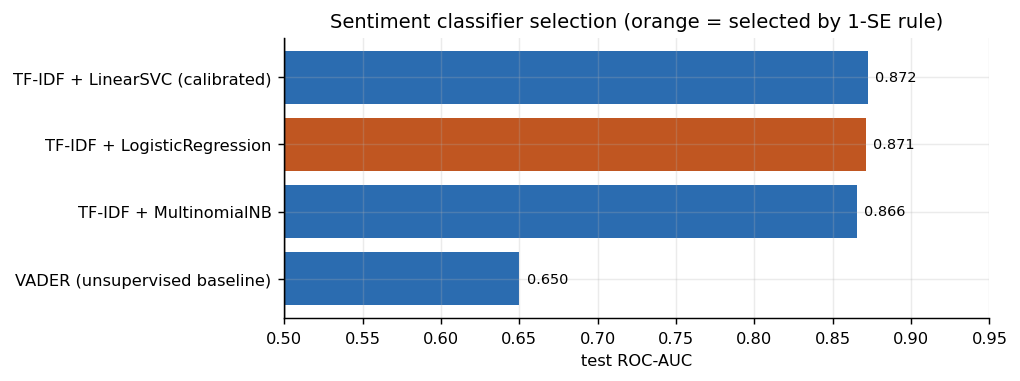

03_model_comparison.png


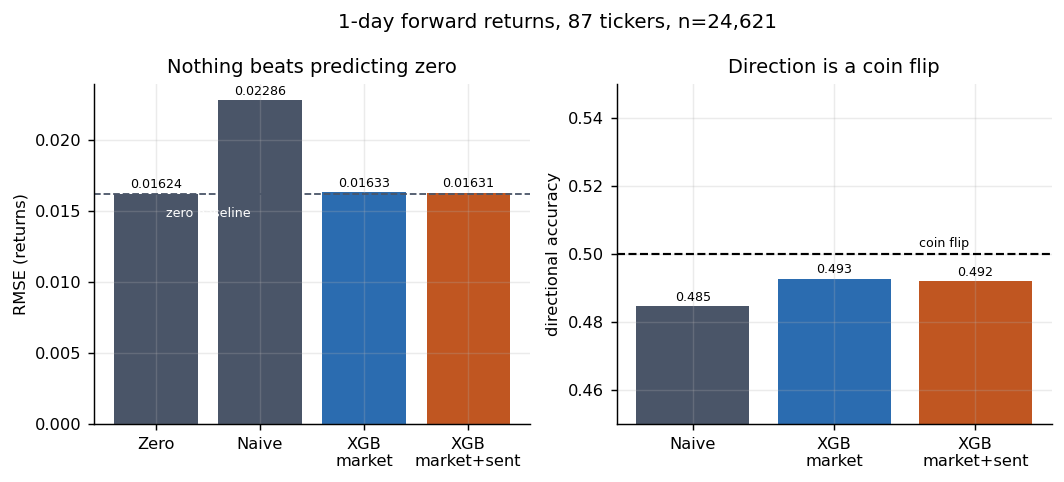

04_ablation.png


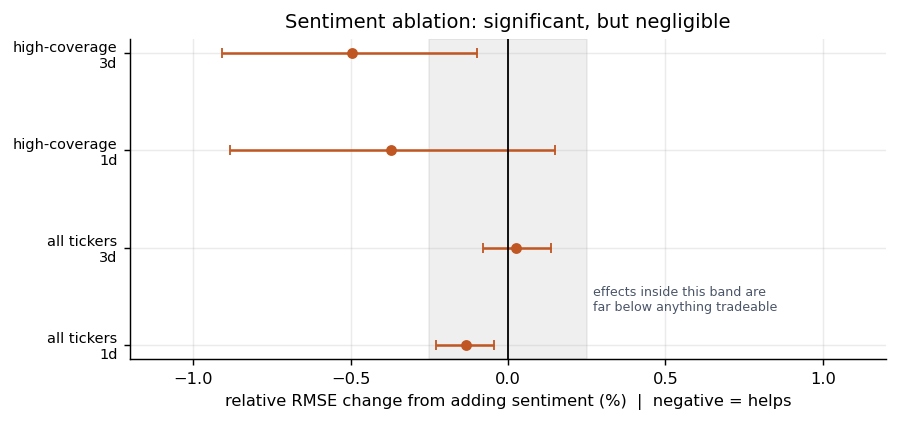

05_robustness.png


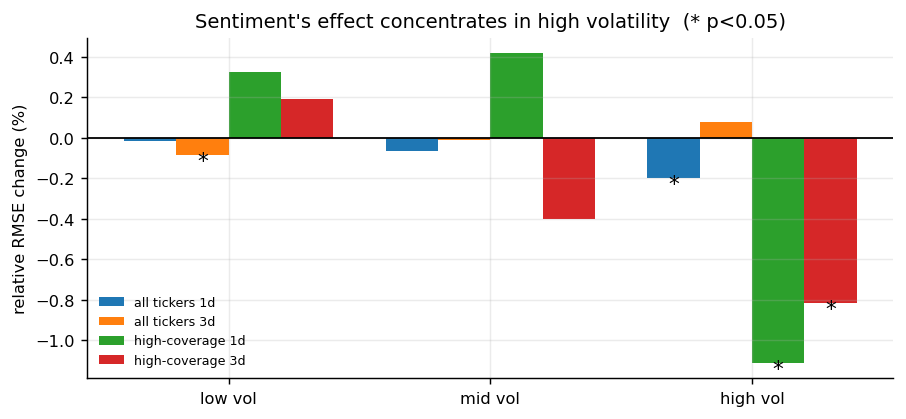

06_per_ticker.png


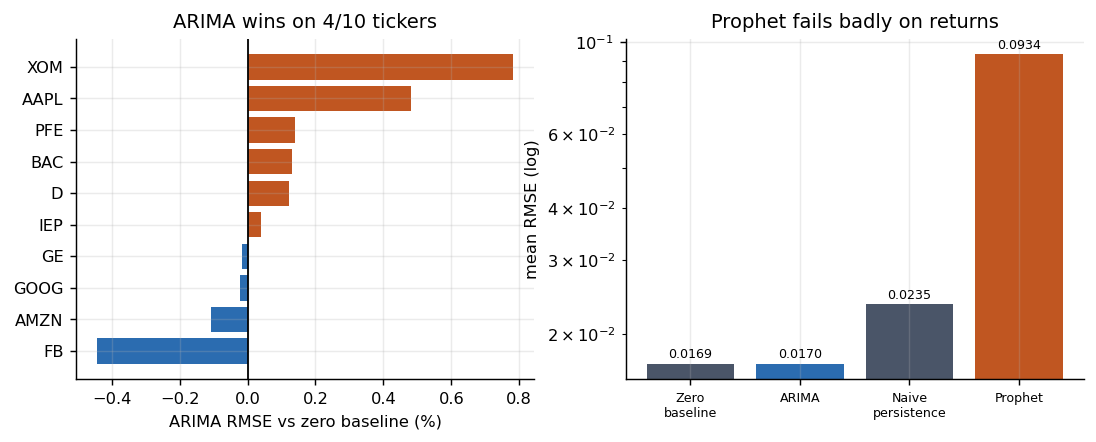

07_series_aapl.png


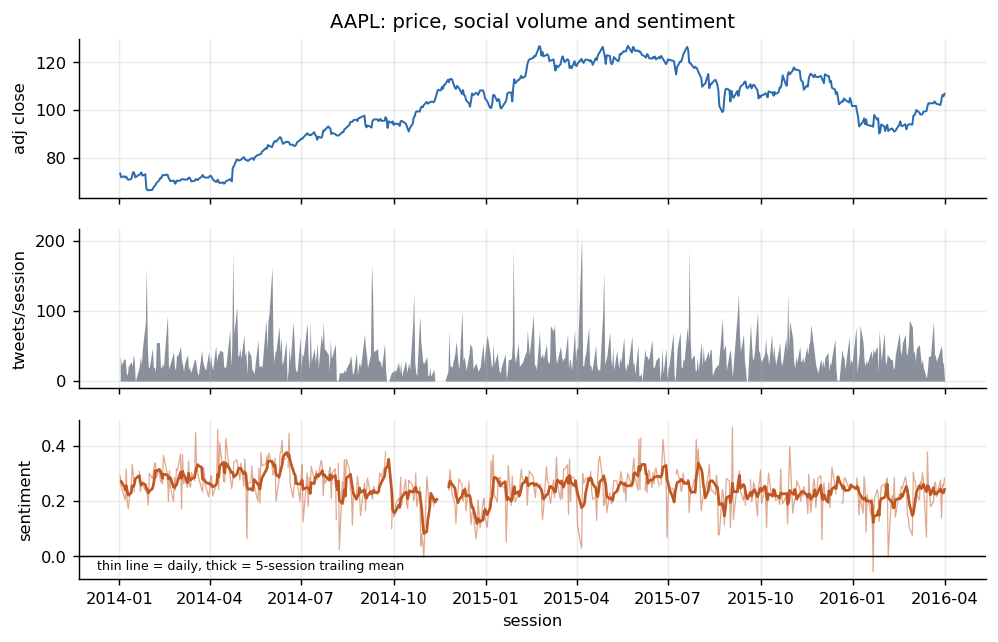

08_actual_vs_pred.png


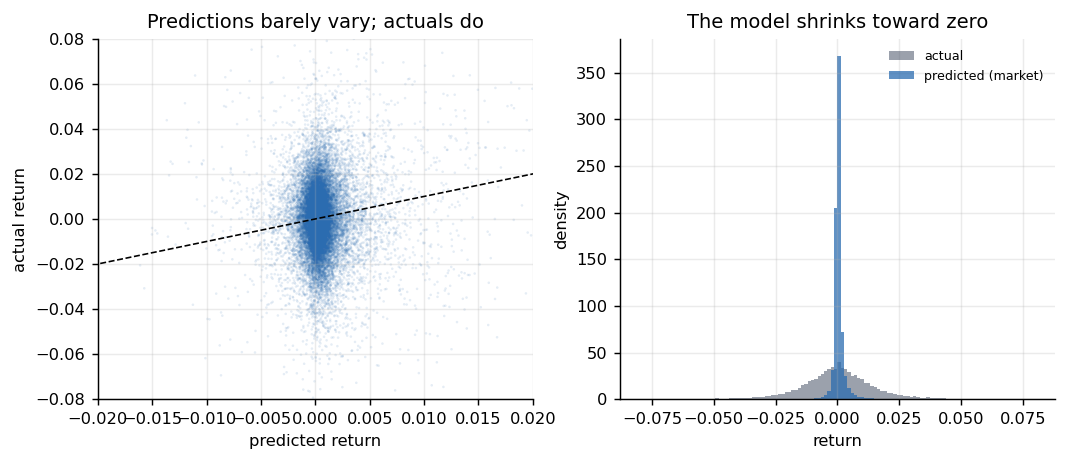

In [14]:
from IPython.display import Image, display
for f in sorted((R / "figures").glob("*.png")):
    print(f.name)
    display(Image(str(f)))